# 05 - Evaluation del Modello di Depression Prediction
Questo notebook completa la fase di modellazione valutando il modello di Gradient Boosting, ottimizzato in fase di validazione, sul **Test Set indipendente** (congelato durante le fasi di sviluppo esplorative). 
Inoltre, esegue un'**Analisi dei Residui** dettagliata volta a comprendere il comportamento clinico e l'affidabilità predittiva rispetto alle fasce standardizzate di severità del test PHQ-9. L'obiettivo primario di SINTON-IA è intercettare eventuali peggioramenti non catturati prima che si manifestino patologicamente nel paziente in coda per l'ASL, onde elevare il suo referto clinico.

In [9]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import os

# Impostazioni grafiche per i plot di SINTON-IA (LaTeX standard)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.figsize'] = (10, 6)

# Path definition
DATA_DIR = '../data/processed'
FIG_DIR = '../../../docs/latex/figures'

# Assicurarsi che la dir figures esista
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Caricamento Dati e Modello

In [10]:
# Caricamento del Test Set isolato precedentemente
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')

# Split target e feature
target_col = 'phq9_total'
columns_to_drop = ['user_id', 'date', target_col]

X_test = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
y_test = test_df[target_col]

# Caricamento Modello Finale
model = joblib.load(f'{DATA_DIR}/final_model_depression.pkl')

# Caricamento Baseline Metrics (Ridge default)
with open(f'{DATA_DIR}/baseline_metrics.json', 'r') as f:
    baseline_metrics = json.load(f)

print(f"Dimensioni Test Set: {X_test.shape[0]} pazienti")
print(f"Numero di Feature: {X_test.shape[1]}")
print(f"Modello Selezionato: {type(model).__name__}")

Dimensioni Test Set: 20000 pazienti
Numero di Feature: 8
Modello Selezionato: LGBMRegressor


## 2. Valutazione Metrica e Confronto Baseline
Valutiamo la generalizzazione del Modello sul set di test calcolando MAE, RMSE e l'indice di determinazione R².

In [11]:
# Effettuiamo la prediction sull'intero Test Set
y_pred = model.predict(X_test)

# Metriche Regressione
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Modello Finale sul Test Set ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

print("\n=== Tabella Comparativa Baseline vs Modello Finale ===")
b_mae = baseline_metrics['metrics']['MAE_mean']
b_rmse = baseline_metrics['metrics']['RMSE_mean']

compare_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Baseline (CV Mean)': [f"{b_mae:.4f}", f"{b_rmse:.4f}"],
    'Final Model (Test)': [f"{mae:.4f}", f"{rmse:.4f}"],
    'Miglioramento Assoluto': [f"{b_mae - mae:.4f}", f"{b_rmse - rmse:.4f}"]
})

display(compare_df)

=== Modello Finale sul Test Set ===
MAE:  2.2458
RMSE: 2.8698
R²:   0.7247

=== Tabella Comparativa Baseline vs Modello Finale ===


,Metric,Baseline (CV Mean),Final Model (Test),Miglioramento Assoluto
0,MAE,2.6716,2.2458,0.4258
1,RMSE,3.3799,2.8698,0.5100


## 3. Analisi dei Residui
Analizziamo visivamente la distribuzione del residuo (Errore di Predizione: $y_{pred} - y_{true}$). Idealmente la distribuzione dovrebbe assomigliare ad una campana Normale centrata sullo 0 e non manifestare sbilanciamenti drastici.

<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\aless\AppData\Local\Temp\ipykernel_12412\1791417692.py:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.plot(x, p, 'k', linewidth=2.5, label=f'Normale Sovrapposta ($\mu={mu:.2f}, \sigma={std:.2f}$)')
C:\Users\aless\AppData\Local\Temp\ipykernel_12412\1791417692.py:12: 

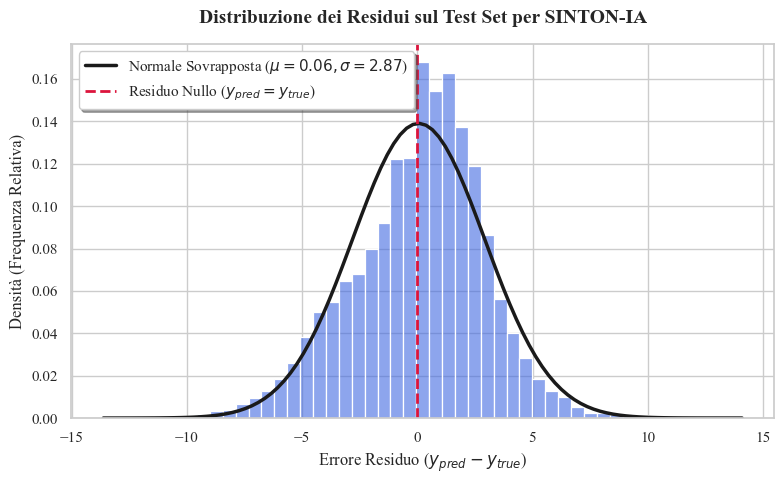

In [12]:
# Calcolo Residui
residuals = y_pred - y_test

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(residuals, bins=45, kde=False, stat='density', alpha=0.6, color='royalblue', ax=ax)

# Aggiunta Fit Normale Sovrapposto
mu, std = stats.norm.fit(residuals)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2.5, label=f'Normale Sovrapposta ($\mu={mu:.2f}, \sigma={std:.2f}$)')

plt.axvline(x=0, color='crimson', linestyle='--', linewidth=2, label='Residuo Nullo ($y_{pred} = y_{true}$)')
plt.title('Distribuzione dei Residui sul Test Set per SINTON-IA', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Errore Residuo ($y_{pred} - y_{true}$)', fontsize=12)
plt.ylabel('Densità (Frequenza Relativa)', fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()

# Salvataggio Artifact (LaTeX)
plt.savefig(f'{FIG_DIR}/dp_residual_distribution.png', bbox_inches='tight')
plt.show()

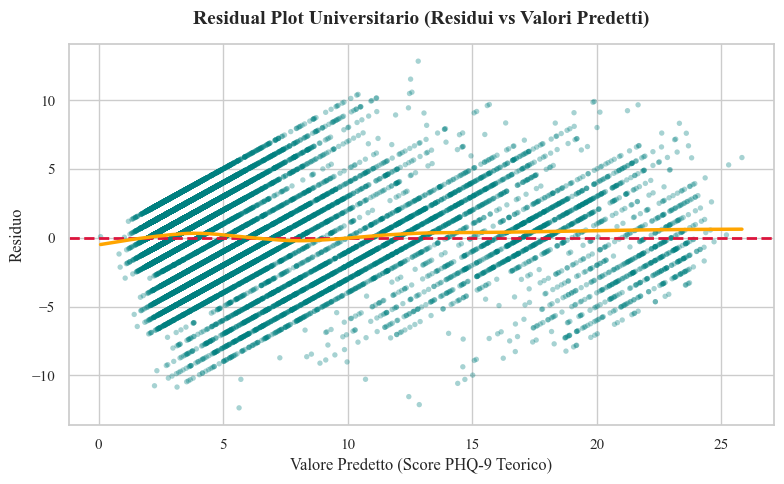

In [13]:
# Residual Plot: esplorazione di eventuali pattern non casuali
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.35, edgecolors='none', color='teal', s=15)
ax.axhline(0, color='crimson', linestyle='--', linewidth=2)

# Linea LOWESS per visualizzare distorsione locale o non-linearità non colte
sns.regplot(x=y_pred, y=residuals, scatter=False, lowess=True, color='orange', line_kws={'linewidth':2.5}, ax=ax)

plt.title('Residual Plot Universitario (Residui vs Valori Predetti)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valore Predetto (Score PHQ-9 Teorico)', fontsize=12)
plt.ylabel('Residuo', fontsize=12)
plt.tight_layout()

plt.savefig(f'{FIG_DIR}/dp_residual_plot.png', bbox_inches='tight')
plt.show()

## 4. Analisi Clinica e Valutazione per Fasce PHQ-9
Il questionario PHQ-9 qualifica lo stato o la severità depressiva tramite specifici "cut-off". 
Fasce Cliniche:
* **0-4**: Assente / Minima (	extit{Minimal})
* **5-9**: Lieve (	extit{Mild})
* **10-14**: Moderata (	extit{Moderate})
* **15-19**: Moderatamente Grave (	extit{Moderately Severe})
* **20-27**: Grave (	extit{Severe})

È fondamentale appurare quanto errore SINTON-IA commetta stratificato per queste etichette.

In [14]:
# Definizione Logica delle Fasce
def get_phq9_band(score):
    if score <= 4: return 'Minima (0-4)'
    elif score <= 9: return 'Lieve (5-9)'
    elif score <= 14: return 'Moderata (10-14)'
    elif score <= 19: return 'Moderat. Grave (15-19)'
    else: return 'Grave (20-27)'

bands_order = ['Minima (0-4)', 'Lieve (5-9)', 'Moderata (10-14)', 'Moderat. Grave (15-19)', 'Grave (20-27)']

analysis_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'residual': residuals,
    'abs_error': np.abs(residuals)
})

analysis_df['band_true'] = analysis_df['y_true'].apply(get_phq9_band)

# Scomposizione Metriche
band_metrics = analysis_df.groupby('band_true').agg(
    MAE=('abs_error', 'mean'),
    N_Pazienti=('abs_error', 'count'),
    RMSE=('residual', lambda x: np.sqrt(np.mean(np.square(x))))
).reset_index()

band_metrics.columns = ['Fascia PHQ-9', 'MAE per Fascia', 'Campioni', 'RMSE per Fascia']
band_metrics['Fascia PHQ-9'] = pd.Categorical(band_metrics['Fascia PHQ-9'], categories=bands_order, ordered=True)
band_metrics = band_metrics.sort_values('Fascia PHQ-9').reset_index(drop=True)

display(band_metrics)

,Fascia PHQ-9,MAE per Fascia,Campioni,RMSE per Fascia
0,Minima (0-4),1.780764,10921,2.329069
1,Lieve (5-9),2.519835,5005,2.969153
2,Moderata (10-14),3.520257,2486,4.222179
3,Moderat. Grave (15-19),2.413891,994,3.079178
4,Grave (20-27),2.871033,594,3.579920


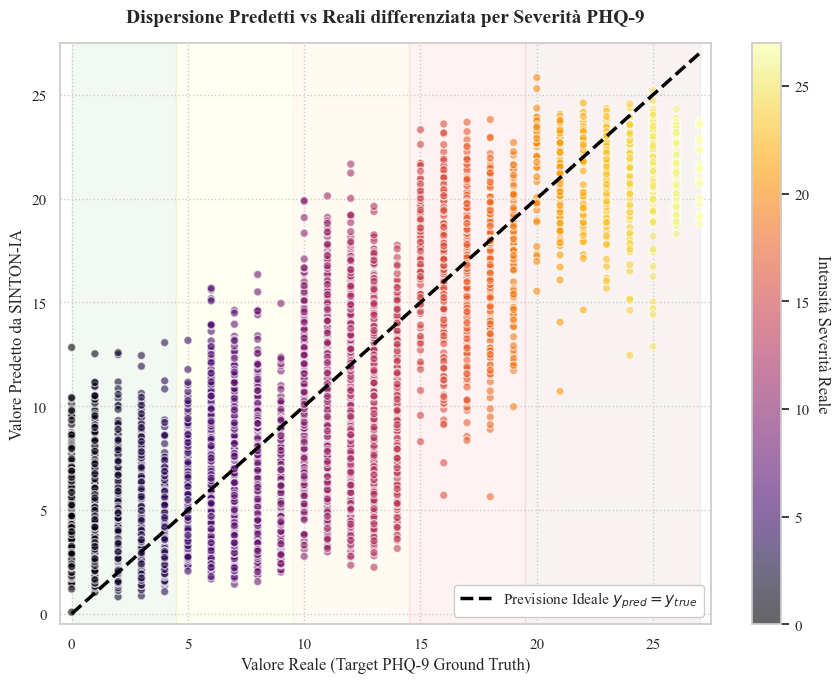

In [15]:
# Valori Predetti vs Valori Reali + Colorazione per Fascia
fig, ax = plt.subplots(figsize=(9, 7))

# Limiti per le fasce cliniche PHQ-9 (visualizzazione) 
bands = [(0, 4.5, 'green', 0.05), (4.5, 9.5, 'yellow', 0.05), (9.5, 14.5, 'orange', 0.05), (14.5, 19.5, 'red', 0.05), (19.5, 27, 'maroon', 0.05)]
for start, end, color, alpha in bands:
    ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)

scatter = ax.scatter(analysis_df['y_true'], analysis_df['y_pred'], alpha=0.6,
                     c=analysis_df['y_true'], cmap='inferno', edgecolors='w', s=35, zorder=2)

ax.plot([0, 27], [0, 27], color='black', linestyle='--', linewidth=2.5, zorder=3, label='Previsione Ideale $y_{pred}=y_{true}$')

plt.title('Dispersione Predetti vs Reali differenziata per Severità PHQ-9', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valore Reale (Target PHQ-9 Ground Truth)', fontsize=12)
plt.ylabel('Valore Predetto da SINTON-IA', fontsize=12)
plt.xlim(-0.5, 27.5)
plt.ylim(-0.5, 27.5)
plt.grid(True, linestyle=':', zorder=1)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Intensità Severità Reale', rotation=270, labelpad=15)
plt.legend(framealpha=1)
plt.tight_layout()

plt.savefig(f'{FIG_DIR}/dp_scatter_pred_vs_true.png', bbox_inches='tight')
plt.show()

## 5. Analisi degli Errori Critici (Falsi Negativi Sostanziali)
In psichiatria, e nell'utilizzo predittivo che farà l'ASL tramite SINTONIA, le 	extbf{sottostime} dei sintomi (quando il modello predice un grave benessere ma il paziente versa in situazione clinica grave) costituiscono il **rischio maggiore.** Tali falsi negativi ostacolano il rialzo di priorità in lista.
Isoliamo i peggiori casi in termini di *residuo negativo* (quindi predetto < reale).

In [16]:
# Ricerca delle più violente Sottostime Cliniche
worst_underestimations = analysis_df.sort_values('residual').head(15)

print(f"I peggiori 15 casi in assoluto presentano una deviazione massima sfavorevole fino a {worst_underestimations.iloc[0]['residual']:.2f} punti.")

display(worst_underestimations[['y_true', 'y_pred', 'band_true', 'residual']].round(2))

I peggiori 15 casi in assoluto presentano una deviazione massima sfavorevole fino a -12.36 punti.


,y_true,y_pred,band_true,residual
17982,18,5.64,Moderat. Grave (15-19),-12.36
2084,25,12.87,Grave (20-27),-12.13
16125,24,12.45,Grave (20-27),-11.55
8237,14,3.15,Moderata (10-14),-10.85
16412,13,2.24,Moderata (10-14),-10.76
15147,25,14.42,Grave (20-27),-10.58
1724,14,3.53,Moderata (10-14),-10.47
13433,14,3.60,Moderata (10-14),-10.40
7570,14,3.68,Moderata (10-14),-10.32
4793,25,14.70,Grave (20-27),-10.30
